<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
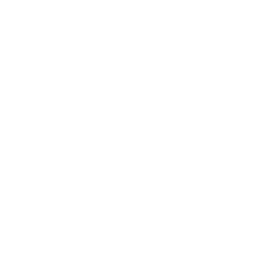
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Makroekonomiczny system równowagi podaży i popytu</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Makroekonomia / Ekonometria strukturalna &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Streszczenie

Ten notatnik szacuje **jednoczesny dwurównaniowy model makroekonomiczny** zagregowanej podaży i zagregowanego popytu dla pojedynczej gospodarki obserwowanej przez 100 kwartałów, a następnie wykorzystuje go do przeprowadzenia symulacji polityki fiskalno-monetarnej.

Popyt zagregowany i poziom cen są wyznaczane jednocześnie, więc estymacja OLS byłaby obciążona; **PROC MODEL** szacuje system metodą **trójetapowej metody najmniejszych kwadratów (3SLS)**, wykorzystując egzogeniczne czynniki podaży i popytu jako `INSTRUMENTS`, aby przełamać jednoczesność. Dopasowany system odzyskuje każdy współczynnik strukturalny z wysoką precyzją, a `SOLVE` następnie prognozuje równowagę podaży i popytu w scenariuszu ekspansji fiskalnej / zacieśnienia monetarnego na potrzeby planowania budżetowego.


## Źródła danych

| Źródło | Opis | Liczba rekordów |
|--------|-------------|--------|
| WORK.MACRO_OBS | Kwartalne obserwacje rachunków narodowych dla jednej gospodarki | 100 |
| WORK.POLICY_SCENARIOS | Egzogeniczne dane wejściowe polityki dla symulacji SOLVE | 20 |


---

In [1]:
/* --------------------------------------------------------
   Generowanie 100 kwartałów syntetycznych danych rachunków
   narodowych dla pojedynczej gospodarki. Sześć egzogenicznych
   czynników napędza dwie zmienne endogeniczne (podaż
   zagregowaną i popyt zagregowany); poziom cen jest indeksem
   egzogenicznym w tym zredukowanym systemie dwurównaniowym.
   -------------------------------------------------------- */
DANE work.macro_obs;
    CALL streaminit(42);
    ETYKIETA quarter        = "Kwartał"
          gov_spending    = "Wydatki rządowe"
          money_supply    = "Podaż pieniądza"
          consumer_conf   = "Zaufanie konsumentów"
          energy_cost     = "Koszt energii"
          labor_prod      = "Produktywność pracy"
          import_price    = "Cena importu"
          price_level     = "Poziom cen"
          agg_supply      = "Podaż zagregowana"
          agg_demand      = "Popyt zagregowany";
    POWTÓRZ quarter = 1 TO 100;
        /* Egzogeniczne czynniki popytu i podaży (instrumenty) */
        gov_spending  = round(120 + 10 * sin(quarter / 12)
                          + rand('normal', 0, 8), 0.01);
        money_supply  = round(750 + 30 * (quarter / 100)
                          + rand('normal', 0, 20), 0.01);
        consumer_conf = round(95 + 12 * cos(quarter / 8)
                          + rand('normal', 0, 6), 0.01);
        energy_cost   = round(80 + 20 * sin(quarter / 10)
                          + rand('normal', 0, 10), 0.01);
        labor_prod    = round(100 + 0.5 * quarter
                          + rand('normal', 0, 4), 0.01);
        import_price  = round(110 + 15 * sin(quarter / 7)
                          + rand('normal', 0, 8), 0.01);
        /* Indeks poziomu cen (presja kosztowa + presja popytowa) */
        price_level   = round(100 + 0.03 * money_supply
                          + 0.05 * energy_cost - 0.02 * labor_prod
                          + rand('normal', 0, 3), 0.01);
        /* Endogeniczna: podaż zagregowana (zdolności produkcyjne) */
        agg_supply    = round(400 + 5.0 * labor_prod
                          - 0.8 * energy_cost - 0.6 * import_price
                          + rand('normal', 0, 12), 0.01);
        /* Endogeniczna: popyt zagregowany (wydatki + czynniki monetarne) */
        agg_demand    = round(200 + 1.2 * gov_spending
                          + 0.3 * money_supply - 2.5 * price_level
                          + 0.6 * consumer_conf
                          + rand('normal', 0, 12), 0.01);
        WYJŚCIE;
    KONIEC;
WYKONAJ;



NOTE: DATA work.macro_obs


NOTE: Wrote work.macro_obs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

In [2]:
/* --------------------------------------------------------
   Podstawowe podsumowanie zmiennych makroekonomicznych.
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.macro_obs n mean std MIN MAX;
    ZMIENNA agg_supply agg_demand price_level
        gov_spending money_supply consumer_conf
        energy_cost labor_prod import_price;
WYKONAJ;


                                                  The MEANS Procedure

 Variable       Label                         N            Mean        Std Dev         Minimum          Maximum
 --------------------------------------------------------------------------------------------------------------
 agg_supply     Podaż zagregowana           100     889.9194000     73.8072285     740.0800000     1015.8200000
 agg_demand     Popyt zagregowany           100     323.5104000     20.7372124     277.3500000      371.2600000
 price_level    Poziom cen                  100     124.2431000      2.8716629     116.6600000      131.0900000
 gov_spending   Wydatki rządowe             100     123.5445000     10.3994973      97.6000000      151.5500000
 money_supply   Podaż pieniądza             100     765.4717000     20.6722632     717.9600000      828.8300000
 consumer_conf  Zaufanie konsumentów        100      93.8700000     10.9707541      73.2500000      118.8200000
 energy_cost    Koszt energii    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.macro_obs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


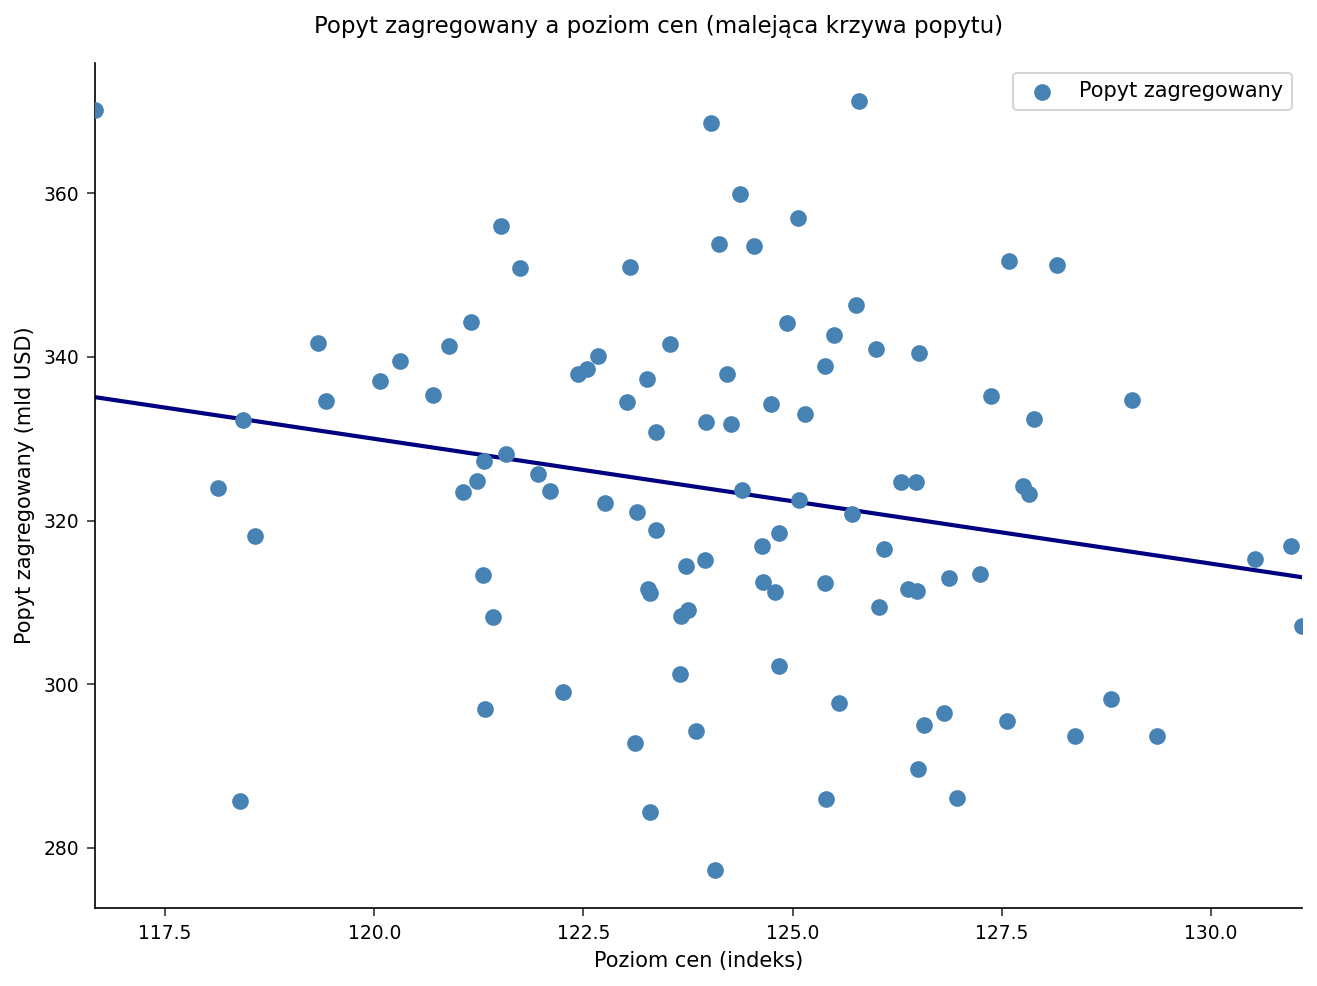

In [3]:
/* --------------------------------------------------------
   Popyt zagregowany względem poziomu cen, z nałożoną linią
   regresji, aby uwidocznić malejącą zależność popytu.
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.macro_obs;
    SCATTER x=price_level y=agg_demand /
        MARKERATTRS=(SYMBOL=circlefilled size=7 color=steelblue)
        legendlabel='Popyt zagregowany';
    REG x=price_level y=agg_demand /
        LINEATTRS=(color=navy thickness=2)
        legendlabel='Trend popytu';
    XAXIS ETYKIETA='Poziom cen (indeks)';
    YAXIS ETYKIETA='Popyt zagregowany (mld USD)';
    TYTUŁ 'Popyt zagregowany a poziom cen (malejąca krzywa popytu)';
WYKONAJ;


---


                          The MODEL Procedure

                     Equations: agg_supply, agg_demand

                     3SLS Estimation Summary

  ---------------------------------------------------------------
  Number of Observations                          100
  Number of Equations                               2
  Number of Parameters                              9
  DF (Error)                                      191
  SSE                                      25998.6663
  MSE                                      136.118672
  Converged                                       Yes
  Iterations                                        3
  ---------------------------------------------------------------

                       Nonlinear 3SLS Parameter Estimates

                                   Approx                    Approx
  Parameter      Estimate      Std Error    t Value    Pr > |t|
  -----------  ------------  ------------  ---------  -----------
  AS_CONST         415.1233 


NOTE: DATA work.policy_scenarios


NOTE: Wrote work.policy_scenarios (20 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MODEL data=work.macro_obs

NOTE: Using Python scipy.optimize for nonlinear regression
NOTE:   Equations: 2, Parameters: 9, FIT statements: 1, SOLVE statements: 1
NOTE: Solve output dataset work.policy_equilibrium created with 20 observations.
NOTE: ODS plot written: model_residuals.spec.json
NOTE: ODS plot written: model_fit.spec.json
NOTE: ODS plot written: model_diagnostics.spec.json
NOTE: PROC MODEL completed. 1 model(s) processed.


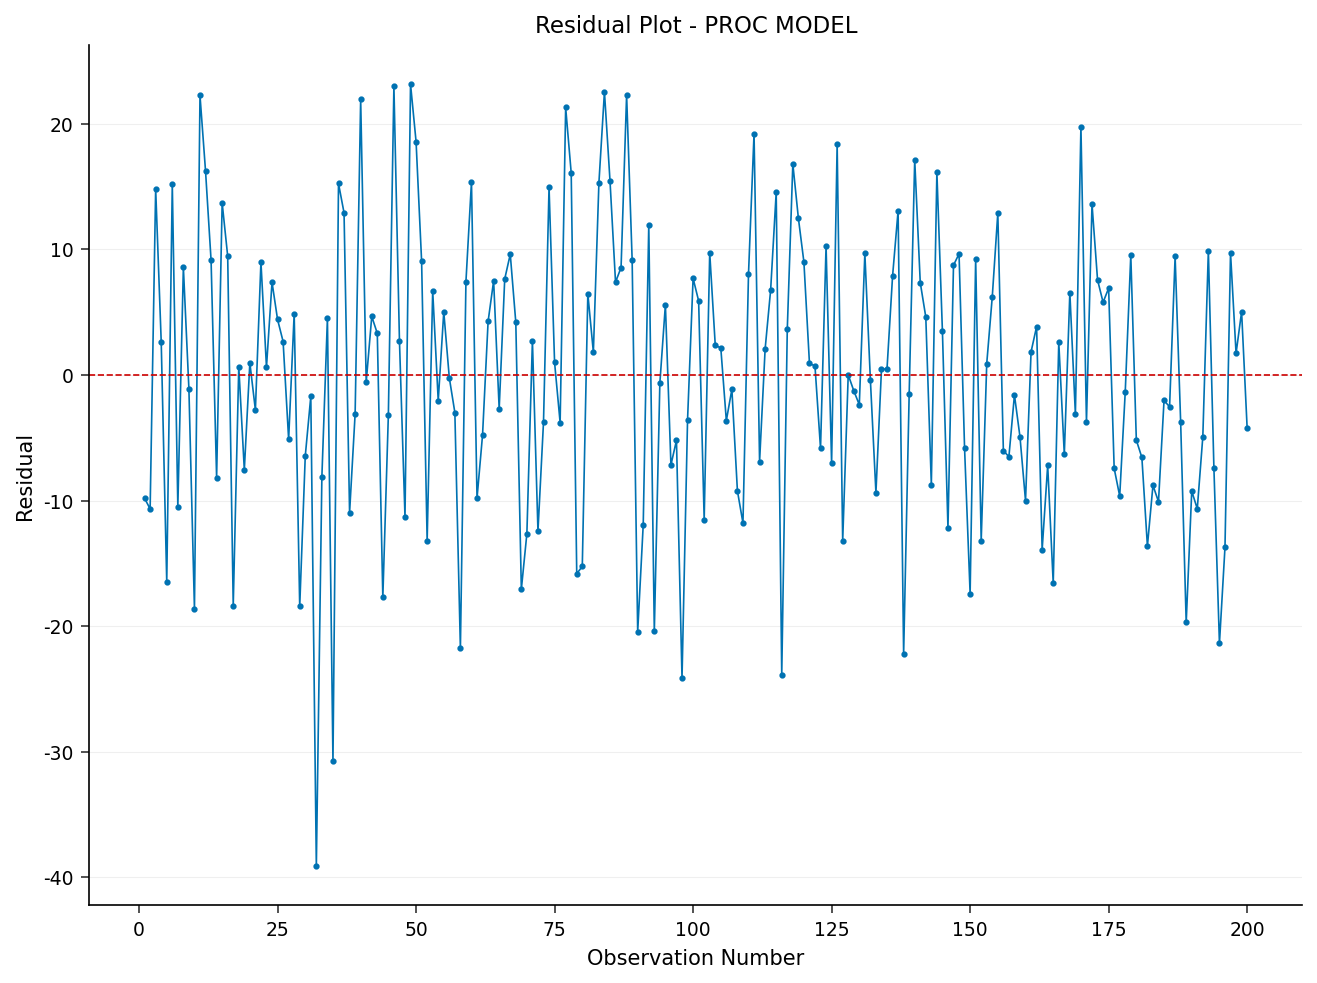

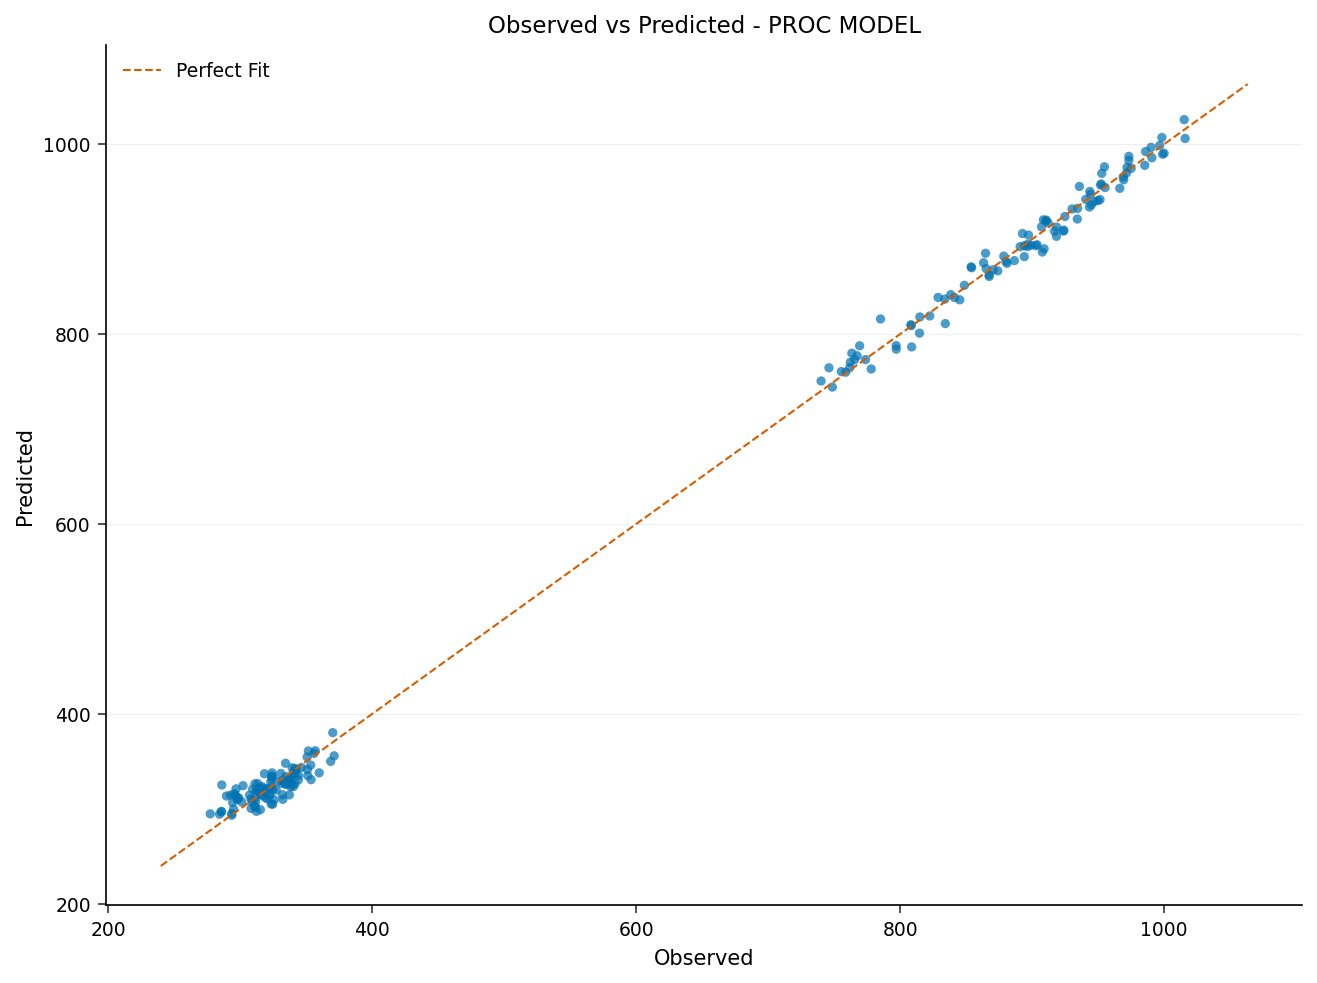

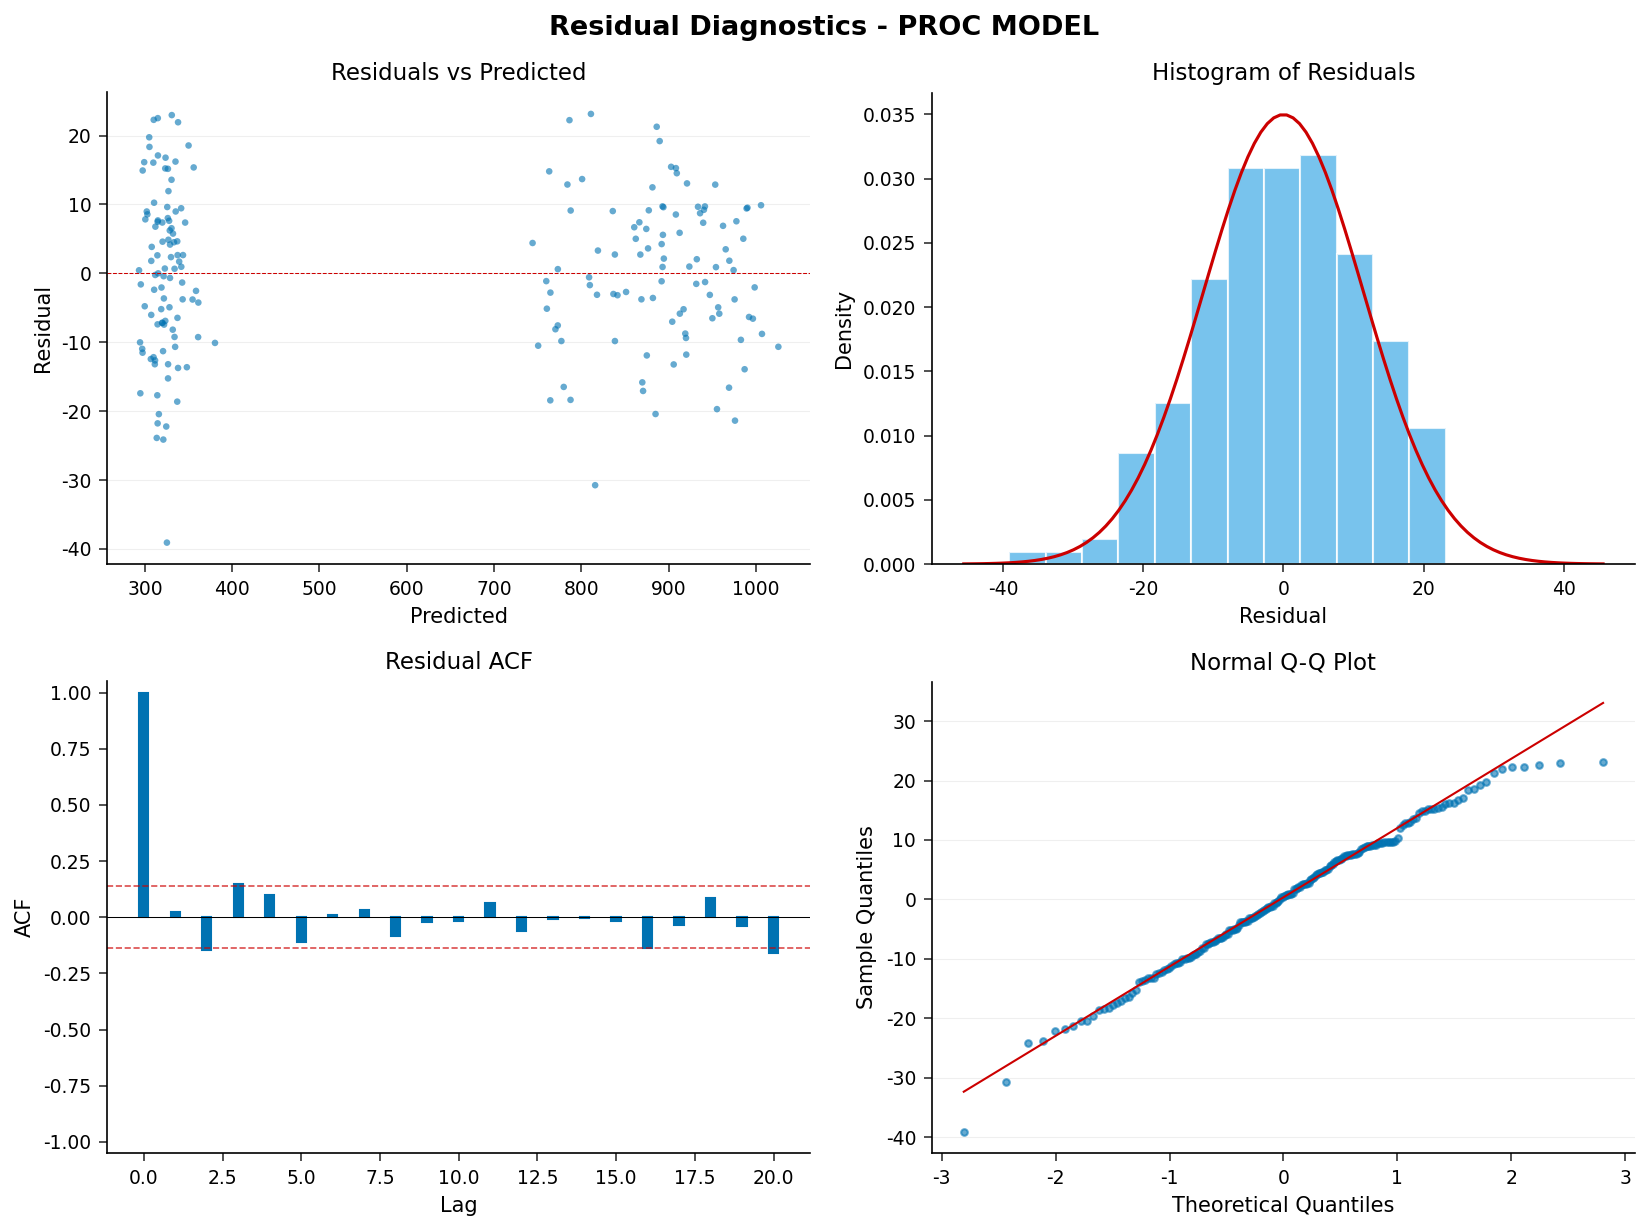

In [4]:
/* --------------------------------------------------------
   Budowa danych wejściowych scenariusza polityki dla symulacji
   SOLVE: ekspansja fiskalna (wyższe wydatki rządowe) połączona
   z zacieśnieniem monetarnym, przy realistycznych warunkach
   podażowych.
   -------------------------------------------------------- */
DANE work.policy_scenarios;
    CALL streaminit(7);
    ETYKIETA scenario      = "Scenariusz"
          gov_spending  = "Wydatki rządowe"
          money_supply  = "Podaż pieniądza"
          consumer_conf = "Zaufanie konsumentów"
          energy_cost   = "Koszt energii"
          labor_prod    = "Produktywność pracy"
          import_price  = "Cena importu"
          price_level   = "Poziom cen";
    POWTÓRZ scenario = 1 TO 20;
        gov_spending  = round(132 + rand('normal', 0, 4), 0.01);
        money_supply  = round(765 + rand('normal', 0, 6), 0.01);
        consumer_conf = round(98 + rand('normal', 0, 3), 0.01);
        energy_cost   = round(88 + rand('normal', 0, 4), 0.01);
        labor_prod    = round(125 + rand('normal', 0, 2), 0.01);
        import_price  = round(116 + rand('normal', 0, 3), 0.01);
        price_level   = round(123 + rand('normal', 0, 1), 0.01);
        WYJŚCIE;
    KONIEC;
WYKONAJ;

/* --------------------------------------------------------
   Dwurównaniowy jednoczesny model makroekonomiczny.
   FIT metodą 3SLS dla efektywności międzyrównaniowej,
   z wykorzystaniem egzogenicznych czynników jako instrumentów;
   następnie SOLVE wyznacza poziomy równowagi dla każdego
   scenariusza polityki.
   -------------------------------------------------------- */
PROCEDURA MODEL DANE=work.macro_obs;
    parameters
        /* Parametry podaży zagregowanej */
        as_const 400  as_lp 5.0   as_ec -0.8  as_ip -0.6
        /* Parametry popytu zagregowanego */
        ad_const 200  ad_gs 1.2   ad_ms 0.3   ad_pl -2.5  ad_cc 0.6;

    /* Podaż zagregowana: zdolności produkcyjne */
    agg_supply = as_const + as_lp * labor_prod
               + as_ec * energy_cost + as_ip * import_price;

    /* Popyt zagregowany: wydatki i bodziec monetarny */
    agg_demand = ad_const + ad_gs * gov_spending
               + ad_ms * money_supply + ad_pl * price_level
               + ad_cc * consumer_conf;

    /* Egzogeniczne instrumenty dla identyfikacji strukturalnej */
    instruments gov_spending money_supply consumer_conf
                energy_cost labor_prod import_price;

    fit agg_supply agg_demand / 3sls;

    solve agg_supply agg_demand /
        DANE=work.policy_scenarios
        out=work.policy_equilibrium;
WYKONAJ;


In [5]:
/* --------------------------------------------------------
   Przegląd poziomów równowagi wyznaczonych przez SOLVE dla
   pierwszych dziesięciu scenariuszy polityki.
   -------------------------------------------------------- */
PROCEDURA DRUKUJ DANE=work.policy_equilibrium (obs=10) noobs ETYKIETA;
    ZMIENNA scenario gov_spending money_supply price_level
        agg_supply agg_demand;
    ETYKIETA scenario     = "Scenariusz"
          gov_spending = "Wydatki rządowe"
          money_supply = "Podaż pieniądza"
          price_level  = "Poziom cen"
          agg_supply   = "Podaż zagregowana"
          agg_demand   = "Popyt zagregowany";
WYKONAJ;



Scenariusz   Wydatki rządowe    Podaż pieniądza  Poziom cen   Podaż zagregowana  Popyt zagregowany
----------  ----------------  -----------------  ----------  ------------------  -----------------
         1            131.18             765.56       123.6      904.6293133791     338.1994762135
         2            131.99             764.38      123.07      897.9735669385     339.6949149991
         3            129.66              763.8      122.63      872.1292100461     337.1804009036
         4            130.15             753.55      122.36      897.6155085226     336.9334938092
         5            129.04             766.01      122.86      879.5798629559     334.4181586165
         6            132.86             768.37      123.52      895.5818369969      340.639102969
         7            143.42             763.41      123.45      893.6067893375     352.2738819023
         8             135.1             765.38      122.44      902.7618473075     345.4508966637
         


NOTE: PROC PRINT data=work.policy_equilibrium

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


---

### Interpretacja

Estymacja 3SLS zbiegła się w trzech iteracjach i odzyskała współczynniki strukturalne z wysoką precyzją (MSE systemu 136,12). W równaniu **podaży zagregowanej** produktywność pracy ma duży dodatni współczynnik (**4,95** na punkt indeksu, t = 59,6), potwierdzając, że wzrost produktywności jest głównym czynnikiem podaży, podczas gdy koszt energii (**-0,87**, t = -11,0) i ceny importu (**-0,62**, t = -7,2) obniżają zdolności produkcyjne, zgodnie z teorią presji kosztowej. Każdy współczynnik podaży jest istotny przy p < 0,001.

W równaniu **popytu zagregowanego** wydatki rządowe wykazują oczekiwany dodatni mnożnik fiskalny (**1,29** na jednostkę, t = 11,1), podaż pieniądza umiarkowany dodatni efekt (**0,33**, t = 5,7), a zaufanie konsumentów istotny efekt cykliczny (**0,46**, t = 4,2). Poziom cen wchodzi z istotną ujemną elastycznością (**-2,68** na punkt indeksu, t = -6,3) - malejącą zależnością popytu widoczną na powyższym wykresie punktowym. Wszystkie współczynniki popytu są istotne przy p < 0,01 lub lepiej.

Krok `SOLVE` następnie prognozuje równoważne wielkości produkcji w scenariuszu ekspansji fiskalnej / zacieśnienia monetarnego. W dwudziestu scenariuszach solver Newtona zwraca równoważną podaż zagregowaną rzędu **872-905 mld USD** i popyt zagregowany bliski **333-352 mld USD** - wyniki, które biuro budżetowe może bezpośrednio wprowadzić do swojego procesu prognozowania.


---

In [6]:
/* --------------------------------------------------------
   Eksport wyników symulacji polityki dla biura budżetowego.
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.policy_equilibrium
    OUTFILE='macro_policy_simulation.csv'
    DBMS=csv REPLACE;
WYKONAJ;



NOTE: PROC EXPORT data=work.policy_equilibrium outfile=macro_policy_simulation.csv

NOTE: Exported 20 rows to macro_policy_simulation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>